# Superstore Sales Analysis

## 1. Data Loading

In [2]:
import pandas as pd

df = pd.read_csv("Sample - Superstore.csv", encoding="latin1")

print(df.head())
print(df.shape)
print(df.columns)

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   Sout

Observation:

The dataset was checked for missing values and duplicate records. No major data quality issues were identified. The dataset is suitable for analysis.

## 2. Data Quality Assessment

In [4]:
print(df.info())
print(df.isnull().sum())
print(df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

Observation:

The dataset contains 9,994 records and 21 variables.
No missing values or duplicate records were identified.
The dataset is clean and suitable for business analysis.

## 3. Monthly Revenue Trend

In [5]:
import matplotlib.pyplot as plt

df["Order Date"] = pd.to_datetime(df["Order Date"])

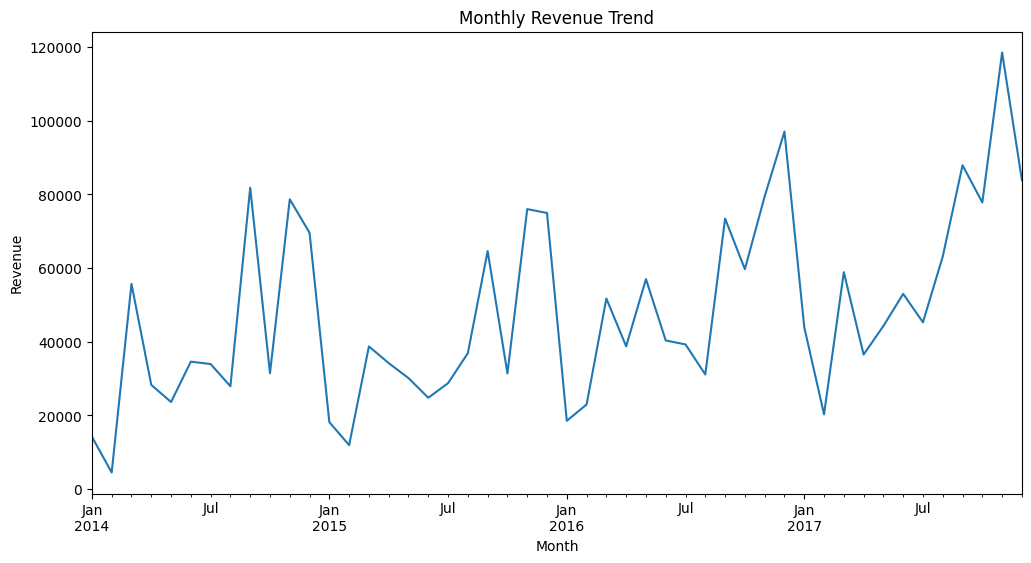

In [6]:
monthly_sales = (
    df.groupby(df["Order Date"].dt.to_period("M"))["Sales"]
    .sum()
)

monthly_sales.plot(figsize=(12,6))

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

Observation:

Monthly revenue exhibits significant variability across the four-year period. While sales fluctuate from month to month, the overall trend is positive, with revenue increasing substantially by 2017. The highest sales levels are recorded in late 2017, and recurring peaks toward year-end indicate that seasonal factors may influence customer purchasing behavior.

## 4. Top Products by Sales

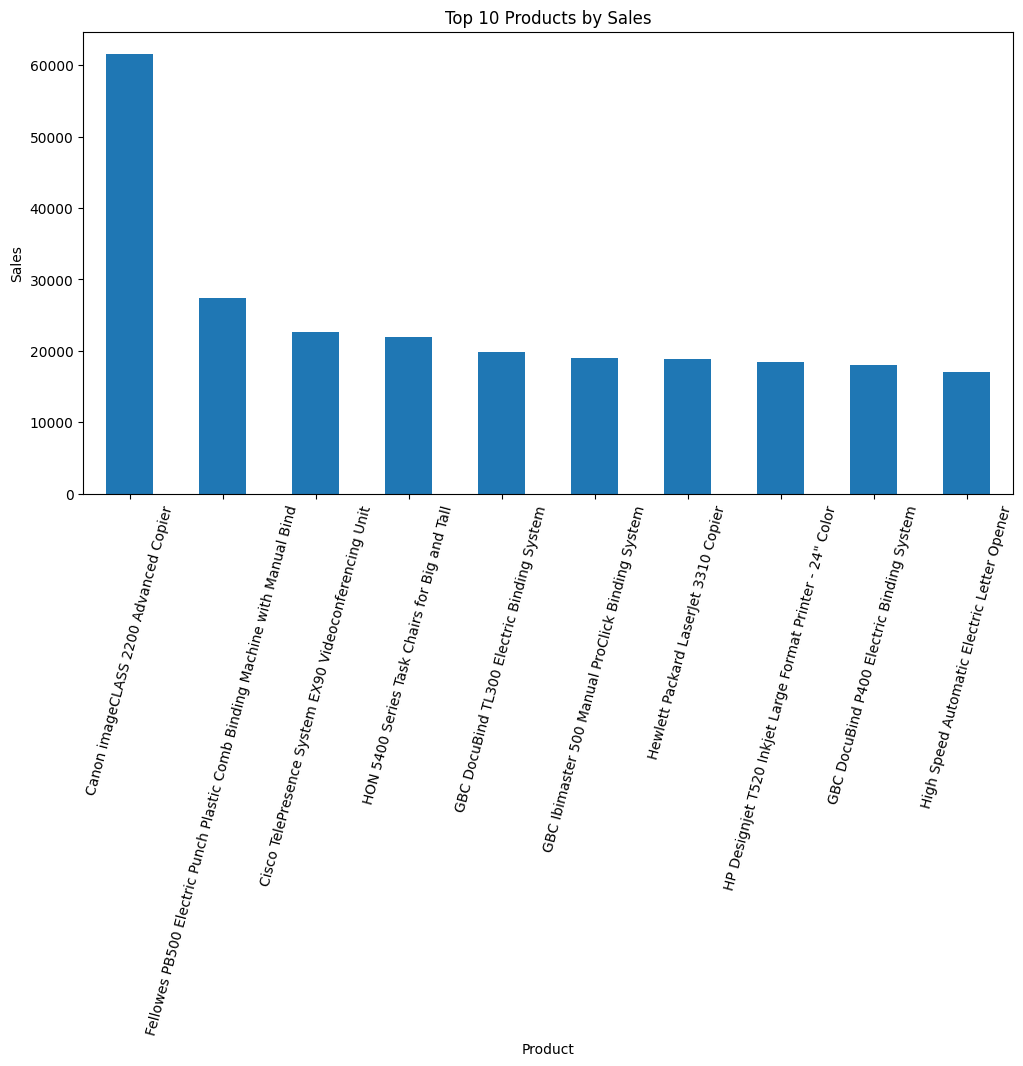

In [8]:
top_products = (
    df.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products.plot(kind="bar", figsize=(12,6))

plt.title("Top 10 Products by Sales")
plt.xlabel("Product")
plt.ylabel("Sales")
plt.xticks(rotation=75)

plt.show()

In [9]:
print(top_products)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


Observation:

Sales are concentrated among a small number of high-performing products. The Canon imageCLASS 2200 Advanced Copier generated the highest sales revenue, significantly outperforming other products. Several of the top-selling products are office technology and business equipment items, indicating strong customer demand within the Technology category.

## 5. Profit Analysis by Category


Category
Furniture           18451.2728
Office Supplies    122490.8008
Technology         145454.9481
Name: Profit, dtype: float64


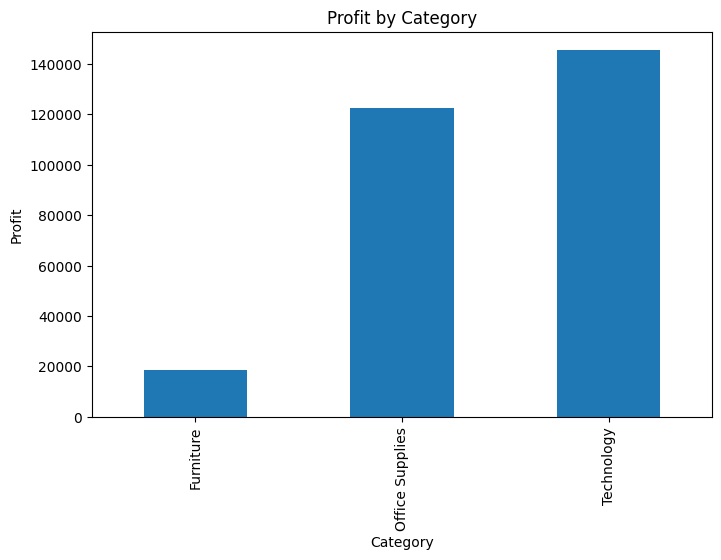

In [10]:
profit_by_category = (
    df.groupby("Category")["Profit"]
    .sum()
)

print(profit_by_category)

profit_by_category.plot(kind="bar", figsize=(8,5))

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.show()

In [11]:
print(profit_by_category)

Category
Furniture           18451.2728
Office Supplies    122490.8008
Technology         145454.9481
Name: Profit, dtype: float64


Observation:

Technology is the most profitable product category, generating approximately $145,455 in profit. Office Supplies is the second most profitable category with over $122,000 in profit. Furniture produces substantially lower profit compared to the other categories, suggesting lower margins or higher operating costs.

Recommendation:

Increase investment in Technology products because they generate the highest profit. Additionally, review Furniture pricing, discount policies, and cost structures to improve profitability.

## 6. Regional Sales Analysis

Region
Central    501239.8908
East       678781.2400
South      391721.9050
West       725457.8245
Name: Sales, dtype: float64


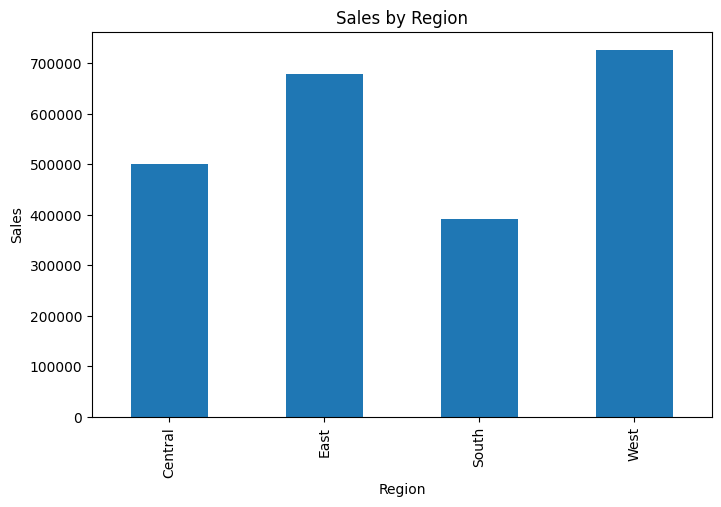

In [12]:
sales_by_region = (
    df.groupby("Region")["Sales"]
    .sum()
)

print(sales_by_region)

sales_by_region.plot(kind="bar", figsize=(8,5))

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.show()

Observation:

The West region generated the highest sales revenue, exceeding $725,000. The East region also performed strongly, while the South region recorded the lowest sales. These results indicate that sales performance varies significantly across regions and that the South region may require additional attention to improve market penetration.

In [13]:
print(sales_by_region)

Region
Central    501239.8908
East       678781.2400
South      391721.9050
West       725457.8245
Name: Sales, dtype: float64


Recommendation:

Develop targeted marketing campaigns and customer acquisition strategies in the South region to increase sales performance. Successful practices from the West region should be evaluated and replicated where appropriate.

## 7. Business Recommendations



1. Increase investment in Technology products because they generate the highest profit and contain several of the best-selling products.

2. Review pricing, discounting, and cost management strategies for Furniture products to improve profitability.

3. Implement targeted growth initiatives in the South region to increase sales and market share.

4. Leverage successful sales strategies used in the West region and apply them to lower-performing regions.

5. Plan promotional campaigns around peak sales periods, particularly during the final months of the year when revenue is highest.

## 8. Conclusion

This analysis examined sales performance, profitability, product performance, and regional trends within the Superstore dataset. Technology emerged as the most profitable category, while the West region generated the highest sales revenue. The business demonstrated overall growth between 2014 and 2017, with strong sales performance during year-end periods. Strategic focus on high-performing products and underperforming regions could further improve business results.